In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from supplements.other_models.visualisation import plot_cm

from transformers import AutoTokenizer
from sklearn.metrics import fbeta_score


In [3]:
from transformers import TFAutoModelForSequenceClassification

model = TFAutoModelForSequenceClassification.from_pretrained("JohannesKlier/esm2_t6_8M_UR50D-finetuned-denovo-classification")



2026-01-26 12:47:08.485824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769428028.525488   83342 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769428028.536963   83342 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769428028.635217   83342 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769428028.635233   83342 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769428028.635235   83342 computation_placer.cc:177] computation placer alr

In [4]:
model_checkpoint = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [ ]:
df = pd.read_csv('test_dataset.csv')

encodings = tokenizer(
    df['sequence'].tolist(),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='tf'
)

In [ ]:
predictions = model.predict({
    'input_ids': encodings['input_ids'],
    'attention_mask': encodings['attention_mask']
})

logits = predictions.logits
pred_labels = np.argmax(logits, axis=1)
true_labels = df['label'].values


48/48 [==============================] - 3s 70ms/step


[[1466    4]
 [   9   37]]


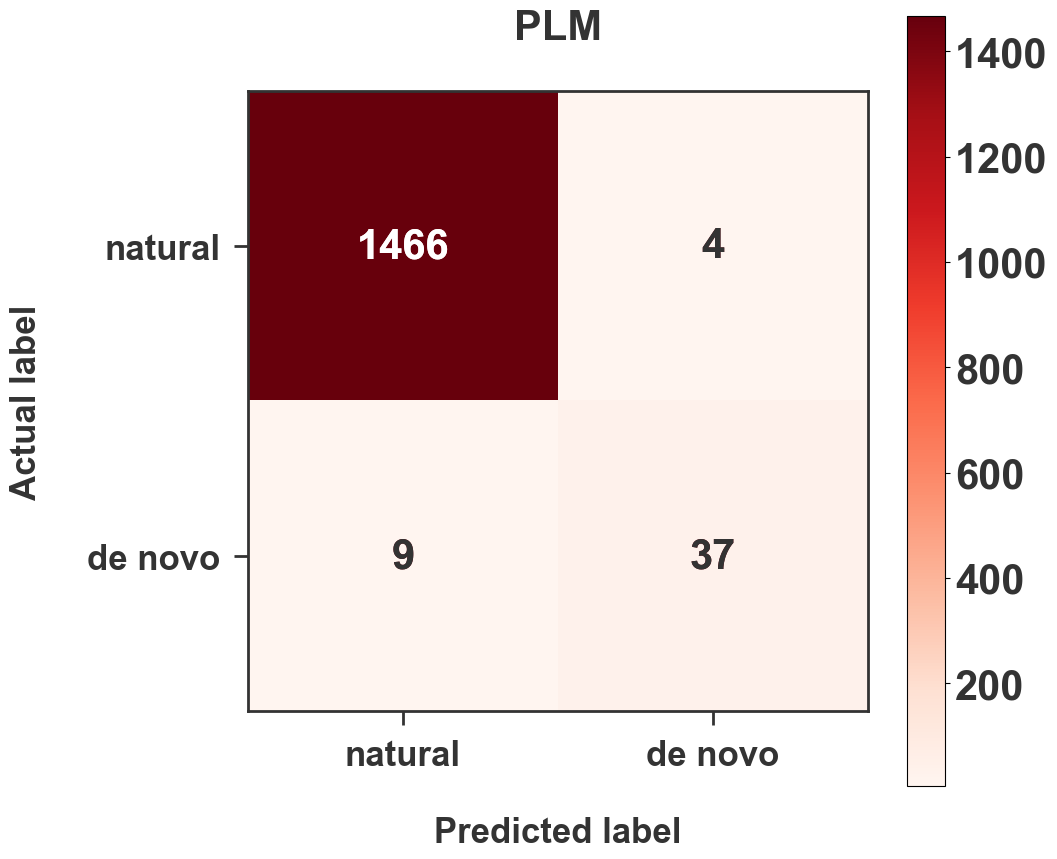

In [ ]:
color = plt.cm.Reds
plot_cm(true_labels, pred_labels, color, 
        title=f"PLM\n", 
        ylabel="Actual label\n", 
        xlabel="\nPredicted label")
plt.savefig("./cm_PLM.png", dpi=300, bbox_inches='tight')

In [32]:
fbeta_score(true_labels, pred_labels >= 0.5, beta=2)

0.8222222222222222